# Final Assignment - Machine Learning

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
sns.set(rc={'figure.figsize':(15, 9)})
sns.set(font_scale=1.5)
sns.set_style('ticks')

The `world_happiness.csv` dataset from the `data` folder contains a series of variables that can be used as a proxy to a country's evaluation of its own goodness of life. The `happiness_score` metric tries to summarise how "happy" each country is. Load and save the dataset to a DataFrame object named `happy`. As always, familiarise yourself with its contents.

1. Using a histogram, plot the distribution of the `happiness_score` variable, **which distribution does it resemble?** (in the answer sheet write the [name of the distribution](https://miro.medium.com/max/962/1*DmPUIjvecL7KllOamoFSDw.png) that best fits the data)

In [2]:
# Load the data into a pd Dataframe named 'happy'
happy = pd.read_csv('data/world_happiness.csv')
happy.sample(5)

,country,social_support,freedom,corruption,generosity,gdp_per_cap,life_exp,happiness_score
119,Ukraine,56.0,141.0,143.0,66.0,8480,70.8,23
61,Portugal,47.0,37.0,135.0,122.0,29300,81.8,90
38,Uzbekistan,11.0,1.0,18.0,29.0,6490,70.7,115
34,Italy,23.0,132.0,128.0,48.0,35800,83.5,120
56,Kazakhstan,19.0,80.0,57.0,57.0,25400,72.8,96


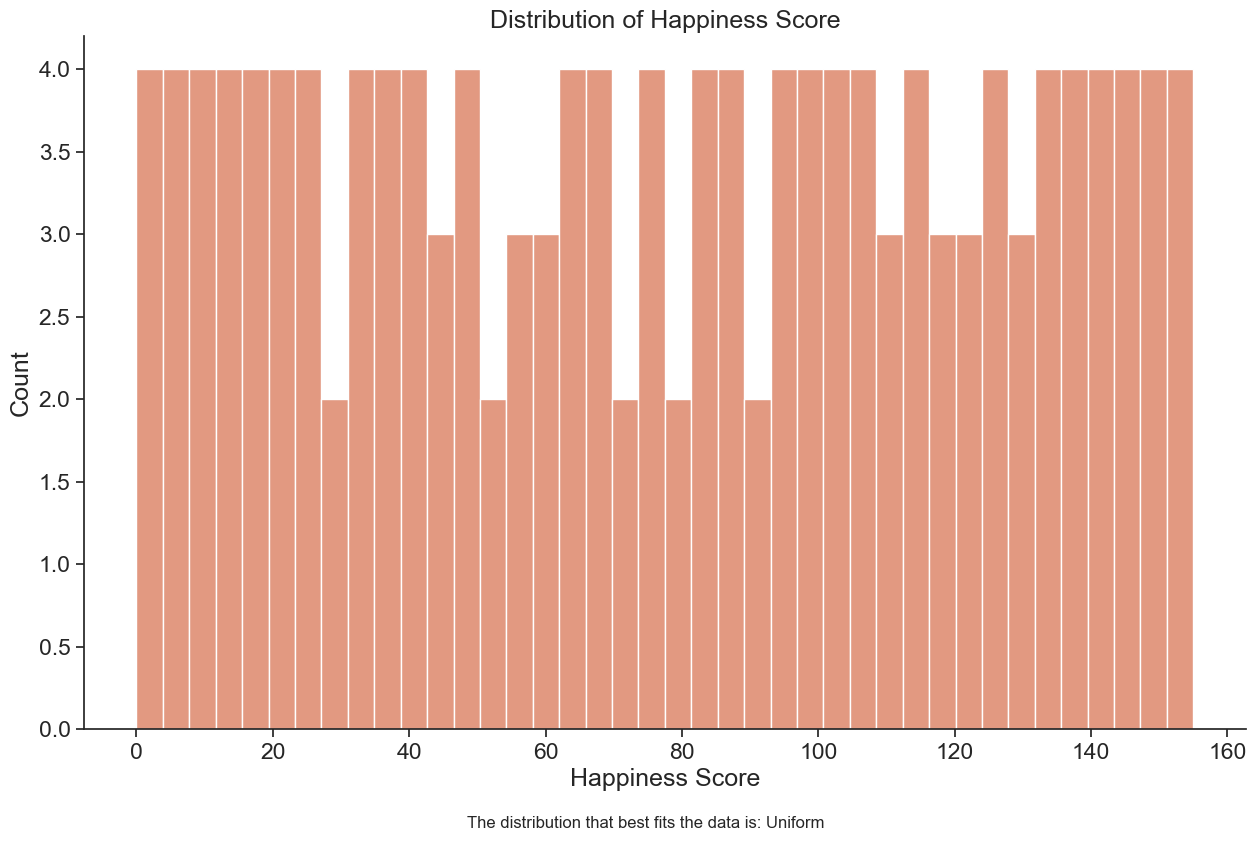

In [3]:
# Visualize 'happiness_score' distrivution with seaborn
sns.histplot(data = happy, x = 'happiness_score', color = '#d97757', bins = 40)
sns.despine()
plt.xlabel('Happiness Score')
plt.ylabel('Count')
plt.title('Distribution of Happiness Score')
plt.figtext(0.5, 0, "The distribution that best fits the data is: Uniform", ha = "center", fontsize = 12)
plt.show()

2. Plot a correlation matrix (or a correlation heatmap) between all the numeric variables in the dataset. **Which variable is the least correlated with the `happiness_score` metric?**

<Axes: >

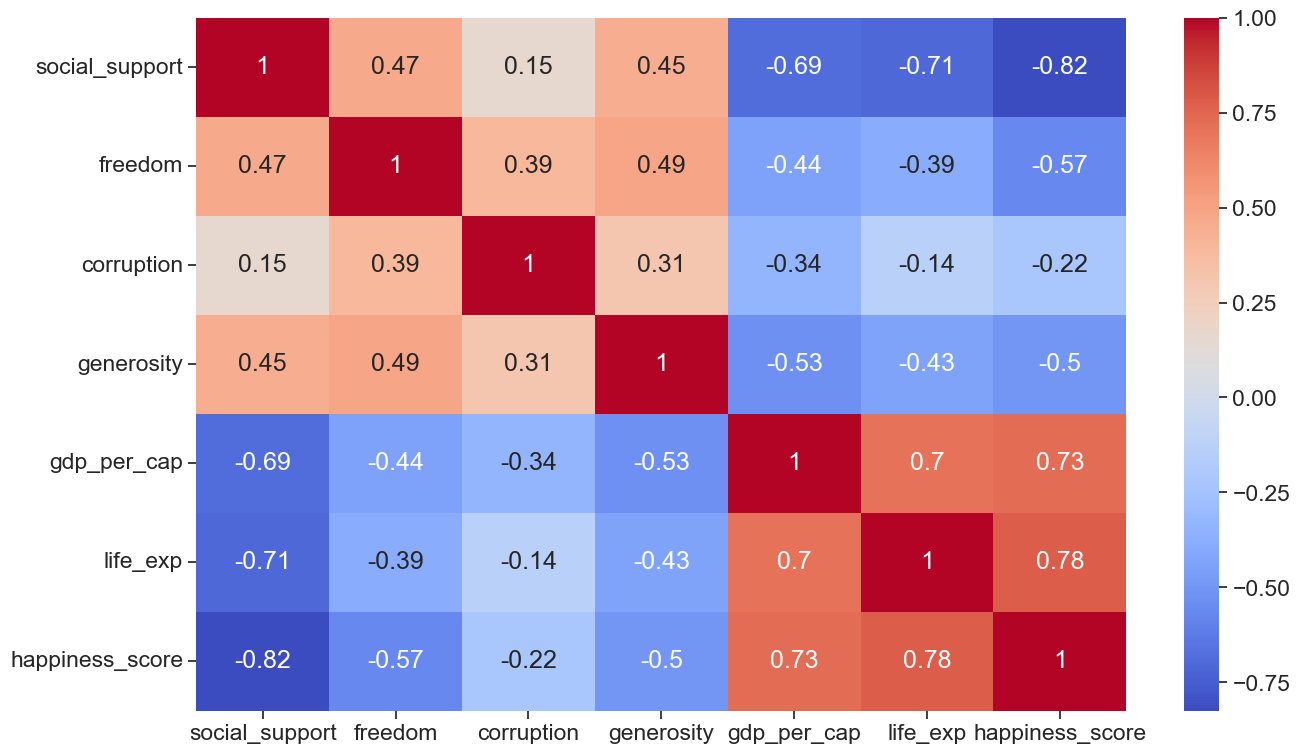

In [4]:
# Remove the column 'country', which is not numeric
happy_c = happy.drop(columns = ['country'])
# Plot the correlation matrix as a heatmap using seaborn
sns.heatmap(happy_c.corr(), annot = True, cmap = 'coolwarm')

In [ ]:
# Calculate absolute correlation with happiness_score (ignoring self-correlation)
least = abs(happy_c.corr()['happiness_score'].drop('happiness_score')).sort_values(ascending = True)

# Print the variable name (index[0]) and its value (iloc[0]) rounded to 3 decimals
print(f"The least correlated variable to the 'happiness_score' is → {least.index[0]}: {least.iloc[0]:.3f}")

The least correlated variable to the 'happiness_score' is → corruption: 0.215


3. You may have noticed that the `corruption` metric has some missing values. **How many countries have a missing corruption value?** After you've answered the question, replace all missing values *in all columns of the DataFrame* with the *respective column's mean value*.

In [6]:
# Calculating how many countries have a missing corruption value
len(happy[happy.corruption.isna()])

8

In [7]:
# Verify which columns have null values:
happy.isna().sum()

country            0
social_support     1
freedom            1
corruption         8
generosity         1
gdp_per_cap        0
life_exp           0
happiness_score    0
dtype: int64

In [8]:
# Replace all missing values in all columns of the DataFrame with the respective column's mean value
happy = happy.fillna(happy.mean(numeric_only=True))

# Verify that all columns have the same number of non-null values:
happy.isna().sum()

country            0
social_support     0
freedom            0
corruption         0
generosity         0
gdp_per_cap        0
life_exp           0
happiness_score    0
dtype: int64

4. Use the `statsmodel` package to create a linear regression model where you use `life_exp` to predict the `happiness_score`. After [refreshing your memory on how to interpret a regression coefficient](https://statisticsbyjim.com/regression/interpret-coefficients-p-values-regression/#:~:text=The%20coefficient%20value%20signifies%20how,in%20isolation%20from%20the%20others.), answer the following question: given the model you just created, **a 1-year increase in life expectancy corresponds to an increase of how many points of the happiness score variable?**.

In [9]:
# Import the statsmodels package
import statsmodels.api as sm

# Define the y and X representing the target and the predictor variables
y = happy.happiness_score
X = happy.life_exp
# manually add a constant to the model
X = sm.add_constant(data = X)
# define the OLS (Ordinary Least Squares) model
model = sm.OLS(endog=y, exog=X)
# fit the regression line to our data
results = model.fit()
# get a summary of the model's statistics
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        happiness_score   R-squared:                       0.609
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                     219.4
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           1.59e-30
Time:                        09:25:37   Log-Likelihood:                -683.97
No. Observations:                 143   AIC:                             1372.
Df Residuals:                     141   BIC:                             1378.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -298.8710     25.536    -11.704      0.000    -349.355    -248.387
life_exp       5.1021      0.344     14.812      0.000       4.421       5.783
==============================================================================
Omnibus:                        7.539   Durbin-Watson:                   1.234
Prob(Omnibus):                  0.023   Jarque-Bera (JB):                6.120
Skew:                          -0.408   Prob(JB):                       0.0469
Kurtosis:                       2.400   Cond. No.                         778.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

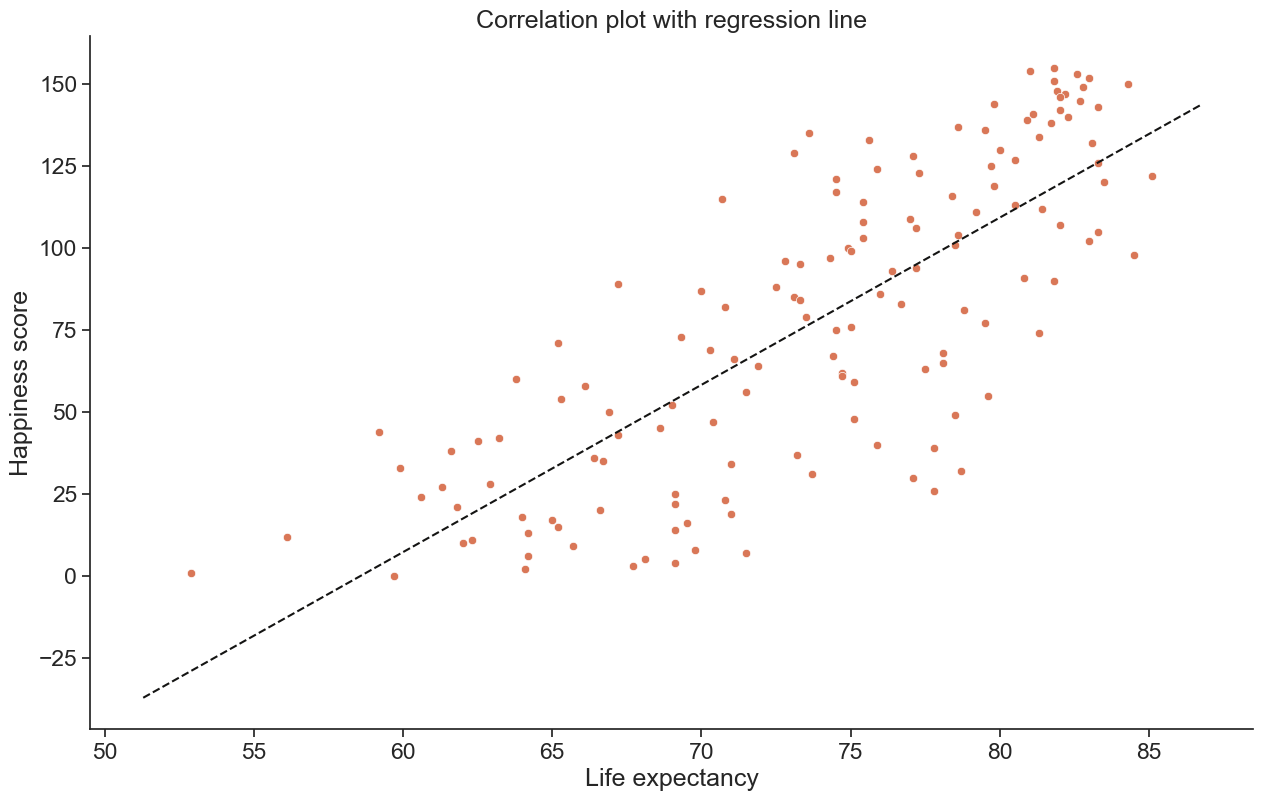

In [ ]:
# Creating the scatterplot
sns.scatterplot(x = 'life_exp', y = 'happiness_score', data = happy, color = '#d97757').set(
    title = 'Correlation plot with regression line',
    xlabel = 'Life expectancy', 
    ylabel = 'Happiness score',)
sns.despine()
axes = plt.gca()   # get axes instance of current figure
x_vals = np.array(axes.get_xlim())   # get x-axis limits
y_vals = results.params.const + results.params.life_exp * x_vals   # define the equation of the regression line
plt.plot(x_vals, y_vals, '--', color='#141413')   # draw the regression line on top of the scatter plot
plt.show()

In [ ]:
# Calculate how many points of the happiness_score will increase for a 1-year increase in life_expectancy
print(f"""For each 1-year increase in the life_expectancy variable (X), 
the happiness_score (y) will increase by {results.params.life_exp:.1f} points""")

For each 1-year increase in the life_expectancy variable (X), the happiness_score (y) will increase by 5.1 points


5. Split the dataset in `train` and `test` sets, leaving 33% of the data in the latter. Then, using the `sklearn` package, train a linear regression model where you try to predict the `happiness_score` using the following set of predictors: `['social_support', 'freedom', 'generosity', 'life_exp']` *(use a `random_state=42`)*. Calculate the R-squared on the train set and compare it with the R-squared based on the test set. **Would you say that the model is overfitting the training data?** Motivate your answer.

In [12]:
# Define the y and X representing the target and the predictor variables
y = happy.happiness_score
X = happy[['social_support', 'freedom', 'generosity', 'life_exp']]

# Import train_test_split package
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Perform the split into 33% test and 66% train with parameter random_state = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)
# define an OLS linear regression model and fit it to the training split
model = LinearRegression()
model.fit(X_train, y_train)
r2_train = model.score(X_train, y_train)
r2_test = model.score(X_test, y_test)

# Print the answer
print(f"""By comparing the R-squared between tre train and test sets we have:
R-squared_train =   {r2_train:.3f}
R-squared_test  =   {r2_test:.3f}
-> Since R-squared_test ~= R-squared_train, it means the model is defenetly not overfitting the the data""")

By comparing the R-squared between tre train and test sets we have:
R-squared_train =   0.785
R-squared_test  =   0.777
-> Since R-squared_test ~= R-squared_train, it means the model is defenetly not overfitting the the data


6. Using the same model from the previous question, **calculate the MAE on the testing set and report it on the answers Sheet.** Are you satisfyied with the model's performance?

In [13]:
# Import mean_absolute_error package from sklearn
from sklearn.metrics import mean_absolute_error

# Generate predictions on the train set and save them into a variable
y_tr_pred = model.predict(X_train)
y_te_pred = model.predict(X_test)

# MAE calculation for train and test sets
mae_tr = mean_absolute_error(y_train, y_tr_pred)
mae_te = mean_absolute_error(y_test, y_te_pred)

# Print the answer
print(f"""By comparing the MAE between tre train and test sets we have:
MAE_train =   {mae_tr:.3f}
MAE_test  =   {mae_te:.3f}
-> Since MAE_test ~= MAE_train, it means the model is defenetly not overfitting the the data""")


By comparing the MAE between tre train and test sets we have:
MAE_train =   16.919
MAE_test  =   17.540
-> Since MAE_test ~= MAE_train, it means the model is defenetly not overfitting the the data


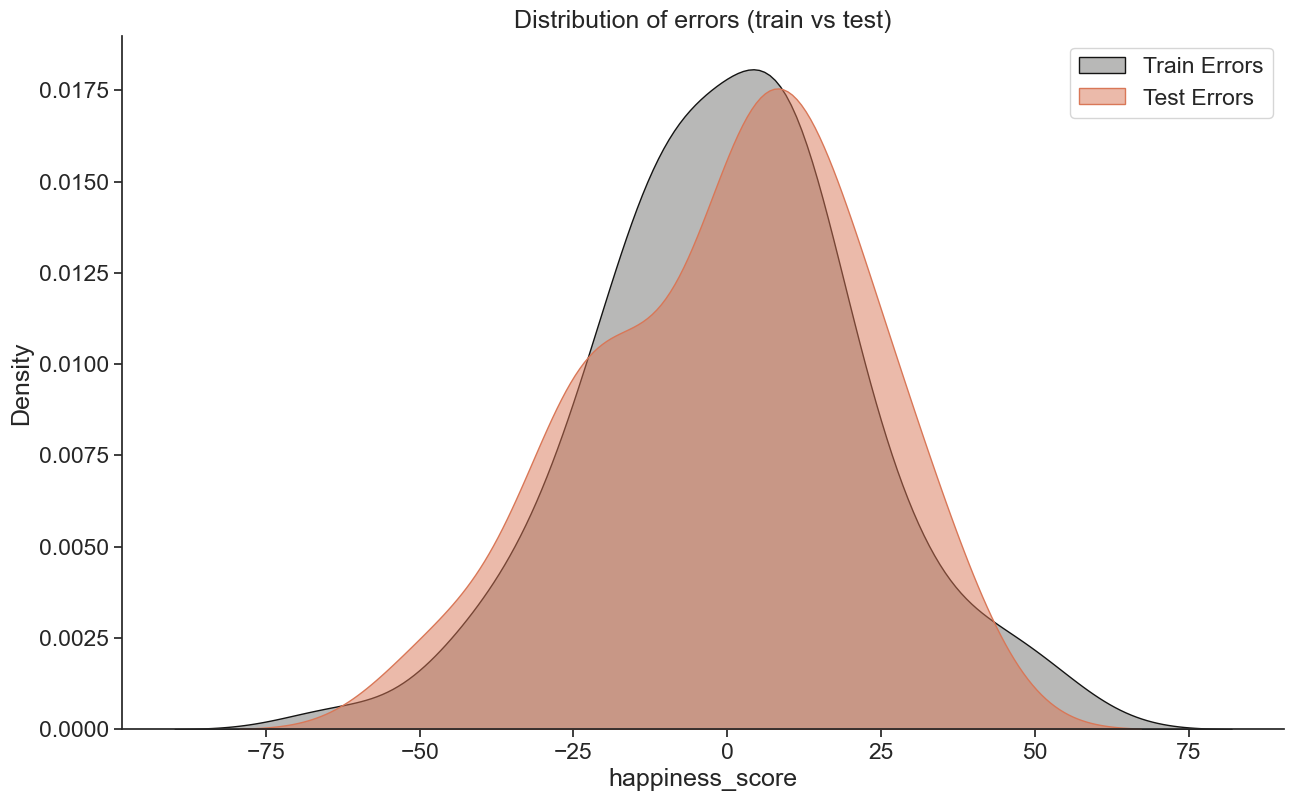

In [14]:
# Distribuzione errori Train
sns.kdeplot((y_train - y_tr_pred), color = '#141413', fill = True, label = 'Train Errors', alpha = 0.3)

# Distribuzione errori Test
sns.kdeplot((y_test - y_te_pred), color = '#d97757', fill = True, label = 'Test Errors', alpha = 0.5)
sns.despine()

# Impostazione del titolo e attivazione legenda
plt.title('Distribution of errors (train vs test)')
plt.legend()
plt.show()

In [15]:
print(f"""Model summary:
In terms of MAE and errors distribution the model accuracy is satisfying:
MAE_train =   {mae_tr:.3f}
MAE_test  =   {mae_te:.3f}

However the R_squared score of {r2_train:.3f} could be defenetly inproved. 
-------------------------------------------------------------------------------------------------------------
-> Adding more correlated variables to the model via data augmentation could help imporving the performances.
-> Another option could be exploring different model from 'multiple linear regression'""")

Model summary:
In terms of MAE and errors distribution the model accuracy is satisfying:
MAE_train =   16.919
MAE_test  =   17.540

However the R_squared score of 0.785 could be defenetly inproved. 
-------------------------------------------------------------------------------------------------------------
-> Adding more correlated variables to the model via data augmentation could help imporving the performances.
-> Another option could be exploring different model from 'multiple linear regression'


### Bonus

11. <span style="color:red">[BONUS]</span> **Do you notice anything strange when looking at the regression coefficients of the model in the previous answer?**

In [ ]:
# Save the list of coefficients and relative values to a pandas Series
coefficients = pd.Series(model.coef_, index=X.columns)

# Print the answer
print(f"""Looking at the regression coefficients of the model:
{coefficients.to_string()}
-> It is strange that only 'life_exp' has a positive correlation with the 'happiness_score',
   all the other parameters are negatively correlated""")

Looking at the regression coefficients of the model:
social_support   -0.511890
freedom          -0.178552
generosity       -0.051773
life_exp          1.810932
-> It is strange that only 'life_exp' has a positive correlation with the 'happiness_score',
   all the other parameters are negatively correlated
